In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from seaborn import kdeplot
from ot.lp import wasserstein_1d as wd
from scipy.stats import t
from triangular_transport.flows.methods.sampling import inf_train_gen

plt.style.use("ggplot")

In [2]:
mcmc_mod = np.load("mcmc_mod_results/avg_wd_mcmc.npy")
mcmc_prior_init = np.load("mcmc_prior_init_results/avg_wd_mcmc.npy")
mcmc_norm = np.load("mcmc_norm_results/avg_wd_mcmc.npy")
mcmc_rare = np.load("mcmc_rare_results/avg_wd_mcmc.npy")
mcmc_mod_std = np.load("mcmc_mod_results/std_wd_mcmc.npy")
sample_no_list = np.load("mcmc_mod_results/sample_no_list.npy")

eval_no_array = np.load("init_data/eval_no_array.npy")
nevals_norm = eval_no_array[0].item()
nevals_mod = eval_no_array[1].item()
nevals_rare = eval_no_array[2].item()

In [3]:
eval_no_array

array([84, 46, 68], dtype=int32)

In [4]:
sample_no_list

array([     2,      4,      8,     16,     32,     64,    128,    256,
          512,   1024,   2048,   4096,   8192,  16384,  20000,  30000,
        40000,  50000,  60000,  70000,  80000,  90000, 100000])

In [5]:
no_trials = 10
ode_array_1 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ode_array_1[i, :] = np.load(f"converge_results_trig_1_regimes/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_norm = np.mean(ode_array_1, axis=0)

ode_array_1 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ode_array_1[i, :] = np.load(f"converge_results_trig_2_regimes/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mod = np.mean(ode_array_1, axis=0)

ode_array_1 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ode_array_1[i, :] = np.load(f"converge_results_trig_3_regimes/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_rare = np.mean(ode_array_1, axis=0)

In [6]:
map_norm = np.linspace(1, mcmc_norm[0], num=len(sample_no_list[0:6]))
map_mod = np.linspace(1, mcmc_mod[0], num=len(sample_no_list[0:6]))
map_rare = np.linspace(1, mcmc_rare[0], num=len(sample_no_list[0:6]))

In [7]:
mcmc_prior_init

array([0.50862846, 0.50899499, 0.50953425, 0.50921224, 0.5067496 ,
       0.50740708, 0.51787732, 0.60975212, 0.77150655, 0.805102  ,
       0.64764335, 0.46797313, 0.31748444, 0.20575464, 0.1817959 ,
       0.14153544, 0.11888366, 0.10301562, 0.09215728, 0.08350603,
       0.07680913, 0.07138063, 0.06669276])

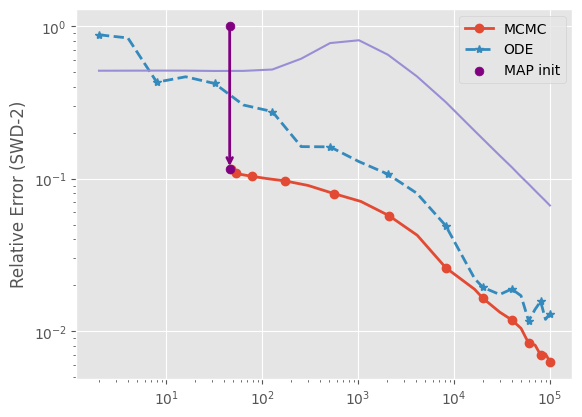

In [8]:
ode_data = ode_mod
mcmc_data = mcmc_mod
map_data = nevals_mod
prior_error_mod = 1 

plt.plot(sample_no_list+map_data, mcmc_data, marker="o", markevery=2, linewidth=2, markersize=6, label="MCMC")
plt.plot(sample_no_list, ode_data, marker="*", linestyle="dashed", linewidth=2, markersize=6, markevery=2, label="ODE")
plt.plot(sample_no_list, mcmc_prior_init)

ax = plt.gca()
ax.annotate("",
    xy=(map_data, mcmc_data[0]),
    xytext=(map_data, prior_error_mod),
    arrowprops=dict(arrowstyle="->", color="purple", lw=2))
ax.scatter([map_data], [prior_error_mod], color="purple", zorder=5, s=40)
ax.scatter([map_data], [mcmc_data[0]], color="purple", zorder=5, s=40, label="MAP init")


plt.yscale("log")
plt.xscale("log")
plt.ylabel("Relative Error (SWD-2)")
plt.legend()

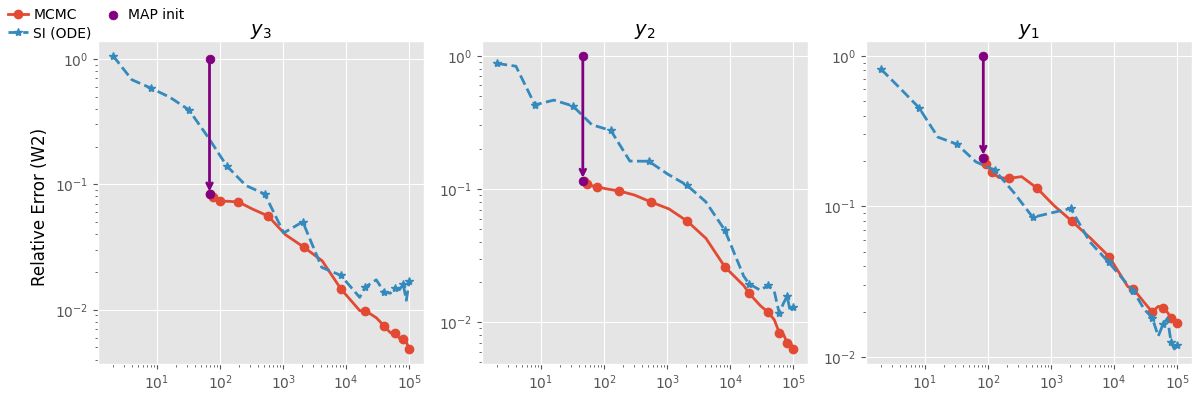

In [10]:
prior_error = 1.0  # error at 2 samples from prior-init chain, proxy for "starting at the prior"

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# --- norm (y=0) ---
ax[2].plot(sample_no_list + nevals_norm, mcmc_norm, marker="o", markevery=2, linewidth=2, markersize=6)
ax[2].plot(sample_no_list, ode_norm, marker="*", linestyle="dashed", linewidth=2, markersize=6, markevery=2)
ax[2].annotate("",
    xy=(nevals_norm, mcmc_norm[0]),
    xytext=(nevals_norm, prior_error),
    arrowprops=dict(arrowstyle="->", color="purple", lw=2))
ax[2].scatter([nevals_norm], [prior_error], color="purple", zorder=5, s=40)
ax[2].scatter([nevals_norm], [mcmc_norm[0]], color="purple", zorder=5, s=40)
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_title(r"$y_1$", fontsize=14, pad=4)

# --- mod (y=-1) ---
ax[1].plot(sample_no_list + nevals_mod, mcmc_mod, marker="o", markevery=2, linewidth=2, markersize=6)
ax[1].plot(sample_no_list, ode_mod, marker="*", linestyle="dashed", linewidth=2, markersize=6, markevery=2)
ax[1].annotate("",
    xy=(nevals_mod, mcmc_mod[0]),
    xytext=(nevals_mod, prior_error),
    arrowprops=dict(arrowstyle="->", color="purple", lw=2))
ax[1].scatter([nevals_mod], [prior_error], color="purple", zorder=5, s=40)
ax[1].scatter([nevals_mod], [mcmc_mod[0]], color="purple", zorder=5, s=40)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title(r"$y_2$", fontsize=14, pad=4)

# --- rare (y=-4.2) ---
ax[0].plot(sample_no_list + nevals_rare, mcmc_rare, marker="o", markevery=2, linewidth=2, markersize=6, label="MCMC")
ax[0].plot(sample_no_list, ode_rare, marker="*", linestyle="dashed", linewidth=2, markersize=6, markevery=2, label="SI (ODE)")
ax[0].annotate("",
    xy=(nevals_rare, mcmc_rare[0]),
    xytext=(nevals_rare, prior_error),
    arrowprops=dict(arrowstyle="->", color="purple", lw=2))
ax[0].scatter([nevals_rare], [prior_error], color="purple", zorder=5, s=40)
ax[0].scatter([nevals_rare], [mcmc_rare[0]], color="purple", zorder=5, s=40, label="MAP init")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_title(r"$y_3$", fontsize=14, pad=4)

fig.supylabel("Relative Error (W2)")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper left",
    ncol=2,
    frameon=False,
    fontsize=10,
    handlelength=1.4,
    handletextpad=0.4,
    columnspacing=0.8,
    labelspacing=0.3,
    borderaxespad=0.2,
)

plt.tight_layout()
plt.savefig("images/lv-conv.pdf")

In [16]:
sample_no_list[5:]

array([    64,    128,    256,    512,   1024,   2048,   4096,   8192,
        16384,  20000,  30000,  40000,  50000,  60000,  70000,  80000,
        90000, 100000])

In [17]:
sample_no_list+64

array([    66,     68,     72,     80,     96,    128,    192,    320,
          576,   1088,   2112,   4160,   8256,  16448,  20064,  30064,
        40064,  50064,  60064,  70064,  80064,  90064, 100064])

In [15]:
sample_no_list


array([     2,      4,      8,     16,     32,     64,    128,    256,
          512,   1024,   2048,   4096,   8192,  16384,  20000,  30000,
        40000,  50000,  60000,  70000,  80000,  90000, 100000])

In [18]:
mcmc_rare

array([0.08314431, 0.08190499, 0.07913013, 0.07699701, 0.07314795,
       0.07321395, 0.07225857, 0.06357664, 0.05575147, 0.03957544,
       0.03160926, 0.02454394, 0.01463799, 0.00982365, 0.00983479,
       0.00862487, 0.00741926, 0.00656408, 0.00651074, 0.00592301,
       0.00588016, 0.00550351, 0.00486295])

In [21]:
mcmc_norm

array([0.21057304, 0.20203208, 0.19036746, 0.18350155, 0.16831936,
       0.1553761 , 0.15309249, 0.15755081, 0.13224221, 0.10133336,
       0.0798033 , 0.06163636, 0.04646589, 0.02930538, 0.02837397,
       0.02297391, 0.01993172, 0.02169509, 0.02124956, 0.01975732,
       0.01826317, 0.01790681, 0.01684474])

In [1]:
import pickle

In [3]:
with open(f"hyperparam_results/best_hyperparams_low.pkl", "rb") as f:
    hyperparams = pickle.load(f)

with open(f"hyperparam_results/best_hyperparams_mid.pkl", "rb") as f:
    hyperparams_mid = pickle.load(f)

with open(f"hyperparam_results/best_hyperparams_high.pkl", "rb") as f:
    hyperparams_high = pickle.load(f)

In [4]:
hyperparams

{'hidden_layer': 124,
 'num_hidden_layers': 9,
 'peak_value': 0.0075130596794,
 'weight_decay': 3.88624552e-05,
 'interpolant': 'linear_interpolant'}

In [5]:
hyperparams_mid

{'hidden_layer': 373,
 'num_hidden_layers': 6,
 'peak_value': 0.0065748068723,
 'weight_decay': 6.80970425e-05,
 'interpolant': 'linear_interpolant'}

In [6]:
hyperparams_high

{'hidden_layer': 287,
 'num_hidden_layers': 5,
 'peak_value': 0.0020049392441,
 'weight_decay': 4.810901e-06,
 'interpolant': 'linear_interpolant'}

In [39]:
np.load("hyperparam_results/incumbent_loss_low.npy")

array([0.06879071])

In [40]:
np.load("hyperparam_results/incumbent_loss_mid.npy")

array([0.04924835])

In [9]:
np.load("hyperparam_results/incumbent_loss_high.npy")

array([0.01462434])